# Petri-Net Primer for MTDSim Stream A

**Author:** Marc Labouchardiere
**Date:** 2026-05-02
**Audience:** myself, planning the SNAKES formalisation between L1 (GAP) and L2 (GASP).

## Purpose

Self-contained learning artifact. Not a literature review, not for inclusion in any submitted document. Reading and running this once should leave me equipped to design the Petri-net formalisation Jin steered toward on 24 April 2026.

## Scope, in order

1. **Foundations** — places, transitions, arcs, tokens, markings, firing rule, reachability graph.
2. **Extensions** — CPN, TPN/SPN, GSPN, SRN. Just the variants relevant here.
3. **Analytical evaluation** — CTMC construction; steady-state, MTTF, expected reward; state explosion.
4. **Mapping to MTDSim** — places ↔ tactics, transitions ↔ GASP edges, tokens ↔ technique IDs, firing rates ↔ scipy variates from `time_generator.py`. Worked example using a real subgraph from `data/gap/gap_v0.4_latest.json`.
5. **SNAKES API tour** — only the constructs section 4 used.
6. **Limitations and open design decisions** — questions, not answers.

## Project context loaded

- [current_state.md](../current_state.md) — Conceptual hierarchy (L0–L4); Stream A; Pivots.
- [src/mtdsim/attacker/gap/schema.py](../src/mtdsim/attacker/gap/schema.py) — `TechniqueNode`, `DependencyEdge`, `TACTIC_ORDER`.
- [src/mtdsim/attacker/gap/selectors/terminal.py](../src/mtdsim/attacker/gap/selectors/terminal.py) — `TerminalObjectiveSelector`.
- [src/mtdsim/attacker/subgraph_profile.py](../src/mtdsim/attacker/subgraph_profile.py) — current sampling-based operationalisation, what the Petri net is an alternative formalism for.
- [src/mtdsim/attacker/profile_generator.py](../src/mtdsim/attacker/profile_generator.py) — `TACTIC_TO_PHASE` (14 → 6 mapping).
- [src/mtdsim/sim/time_generator.py](../src/mtdsim/sim/time_generator.py) — scipy variates the firing-rate cells reuse.


---

## 0. Setup

SNAKES is not currently in `environment.yml`. The cell below installs it on demand. If/when this notebook becomes load-bearing, lift the dependency into the env file.


In [1]:
import importlib, subprocess, sys
if importlib.util.find_spec('snakes') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'snakes'])

import json, math, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import Image, display

import snakes.plugins
snakes.plugins.load('gv', 'snakes.nets', 'nets_gv')
from nets_gv import PetriNet, Place, Transition, Variable, Expression, Value

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from mtdsim.attacker.gap.schema import (
    GeneralisedAttackProfile, TACTIC_ORDER, DependencyEdge,
)
from mtdsim.attacker.gap.selectors.terminal import TerminalObjectiveSelector
from mtdsim.attacker.profile_generator import TACTIC_TO_PHASE
from mtdsim.sim import time_generator

GAP_PATH = REPO_ROOT / 'data' / 'gap' / 'gap_v0.4_latest.json'
with open(GAP_PATH) as f:
    gap = GeneralisedAttackProfile.from_dict(json.load(f))

RNG_SEED = 0
np.random.seed(RNG_SEED)
random.seed(RNG_SEED)

print(f'GAP v{gap.version} loaded: {len(gap.nodes)} techniques, {len(gap.edges)} edges')


GAP v0.4 loaded: 216 techniques, 383 edges


---

## 1. Foundations

A **Petri net** (Murata, 1989) is a bipartite directed graph $N = (P, T, F)$ where $P$ is a finite set of *places*, $T$ is a finite set of *transitions* disjoint from $P$, and $F \subseteq (P \times T) \cup (T \times P)$ is a *flow relation* — there are no arcs from a place to another place or transition-to-transition. Arcs may carry an integer *weight*; unweighted is shorthand for weight 1.

A **marking** $M : P \to \mathbb{N}$ assigns a non-negative integer of *tokens* to each place. The marking is the dynamic state of the net. Tokens are the abstraction that does the work in the formalism: depending on interpretation they stand for messages, resources, control, or — for our purposes — discrete attacker progress.

A transition $t \in T$ is **enabled** at marking $M$ when every input place $p \in {}^\bullet t$ holds at least $w(p, t)$ tokens, where ${}^\bullet t = \{p : (p, t) \in F\}$ is the *preset* of $t$. **Firing** an enabled transition produces marking $M'$ with $M'(p) = M(p) - w(p, t) + w(t, p)$ — tokens are consumed from the preset and produced into the postset $t^\bullet$. Firings are atomic and instantaneous in the basic formalism. Non-determinism is intrinsic: at any marking, multiple transitions may be enabled, and the model does not say which fires.

The set of markings reachable from an initial marking $M_0$ by some sequence of firings is the **reachability set** $R(M_0)$. Connecting these markings by single firings gives the **reachability graph**, a labelled directed graph whose vertices are markings and whose edges are firings. The reachability graph is the fundamental object of analysis: most behavioural properties (boundedness, liveness, reversibility, deadlock-freedom) are predicates on this graph (Murata 1989, §III–V). When the net is finite-state — i.e. the reachability set is finite — these are decidable; in general they need not be.

Two structural properties matter even in this introductory pass. A net is **k-bounded** if no place ever holds more than $k$ tokens in any reachable marking; 1-bounded nets are *safe*. **Conservation** holds if the total token count (or a weighted sum) is invariant under firing — useful when tokens model resources that can move but not be created or destroyed. Both properties limit the size of $R(M_0)$ and so condition the tractability of the analytical evaluation in §3.

A small worked example fixes the picture. Take three places $p_1, p_2, p_3$ and two transitions $t_1, t_2$ with arcs $p_1 \to t_1 \to p_2$ and $p_2 \to t_2 \to p_3$. Initial marking $M_0 = (2, 0, 0)$. The reachability set is $\{(2,0,0), (1,1,0), (0,2,0), (1,0,1), (0,1,1), (0,0,2)\}$ — six markings, the count of distinct $(M(p_1), M(p_2), M(p_3))$ assignments consistent with conservation $M(p_1) + M(p_2) + M(p_3) = 2$. The marking $(0, 0, 2)$ is a *deadlock* (no transition is enabled). The cell below builds this net in SNAKES and fires it through one execution.

Throughout this section we are working with *ordinary place/transition* nets: untyped tokens, no time, no probability. Sections 2–3 layer those features on.


M0: M = (p1=2, p2=0, p3=0)
after t1: M = (p1=1, p2=1, p3=0)
after t1 again: M = (p1=0, p2=2, p3=0)
after t2: M = (p1=0, p2=1, p3=1)


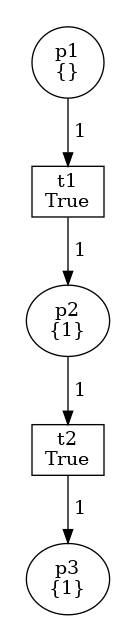

In [2]:
# 1.2 — Three-place / two-transition net, two firings.
n1 = PetriNet('foundations_demo')
n1.add_place(Place('p1', [1, 1]))   # two black tokens
n1.add_place(Place('p2', []))
n1.add_place(Place('p3', []))
n1.add_transition(Transition('t1'))
n1.add_transition(Transition('t2'))
n1.add_input('p1', 't1', Value(1))
n1.add_output('p2', 't1', Value(1))
n1.add_input('p2', 't2', Value(1))
n1.add_output('p3', 't2', Value(1))

def show_marking(net, label):
    m = net.get_marking()
    counts = {p: len(list(m(p))) if p in m else 0 for p in ('p1', 'p2', 'p3')}
    print(f'{label}: M = (p1={counts["p1"]}, p2={counts["p2"]}, p3={counts["p3"]})')

show_marking(n1, 'M0')
n1.transition('t1').fire(n1.transition('t1').modes()[0])
show_marking(n1, 'after t1')
n1.transition('t1').fire(n1.transition('t1').modes()[0])
show_marking(n1, 'after t1 again')
n1.transition('t2').fire(n1.transition('t2').modes()[0])
show_marking(n1, 'after t2')

diag_path = REPO_ROOT / 'notebooks' / '_petri_primer_assets' / 'foundations.png'
diag_path.parent.mkdir(exist_ok=True)
n1.draw(str(diag_path))
display(Image(str(diag_path)))


|R(M0)| = 6 reachable markings, 6 firings
   (0,0,2)
   (0,1,1)
   (0,2,0)
   (1,0,1)
   (1,1,0)
   (2,0,0)


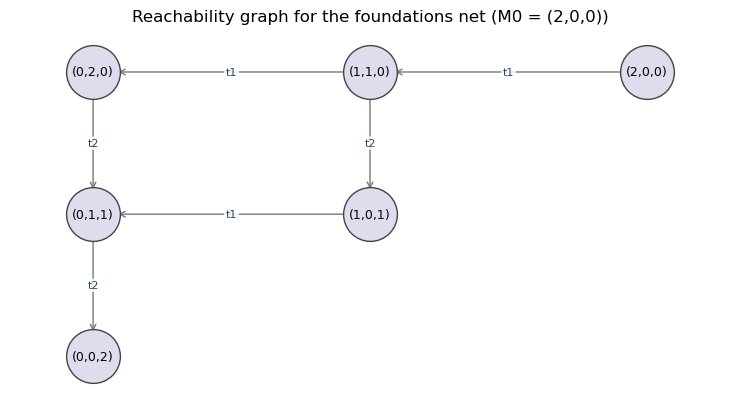

In [3]:
# 1.3 — Enumerate the reachability graph and plot it.
from collections import deque

def reachability_graph(net_factory, transition_names):
    """Breadth-first enumeration of (marking, fired_t, next_marking) edges.

    Markings are encoded as tuples for hashability. ``net_factory`` rebuilds
    the net at a given marking — SNAKES nets do not deep-copy cleanly, so we
    re-construct from the marking each time.
    """
    seen = {}
    edges = []
    init_marking = net_factory(None).get_marking()
    init_key = marking_to_tuple(init_marking)
    queue = deque([init_key])
    seen[init_key] = init_marking
    while queue:
        mk = queue.popleft()
        net = net_factory(mk)
        for t in transition_names:
            tr = net.transition(t)
            for binding in tr.modes():
                net2 = net_factory(mk)
                net2.transition(t).fire(binding)
                nk = marking_to_tuple(net2.get_marking())
                edges.append((mk, t, nk))
                if nk not in seen:
                    seen[nk] = net2.get_marking()
                    queue.append(nk)
    return seen, edges

PLACES_N1 = ('p1', 'p2', 'p3')
def marking_to_tuple(m):
    return tuple((p, len(list(m(p))) if p in m else 0) for p in PLACES_N1)

def make_n1(at=None):
    net = PetriNet('rg')
    counts = dict(at) if at else {'p1': 2, 'p2': 0, 'p3': 0}
    net.add_place(Place('p1', [1] * counts.get('p1', 0)))
    net.add_place(Place('p2', [1] * counts.get('p2', 0)))
    net.add_place(Place('p3', [1] * counts.get('p3', 0)))
    net.add_transition(Transition('t1'))
    net.add_transition(Transition('t2'))
    net.add_input('p1', 't1', Value(1))
    net.add_output('p2', 't1', Value(1))
    net.add_input('p2', 't2', Value(1))
    net.add_output('p3', 't2', Value(1))
    return net

markings, fire_edges = reachability_graph(make_n1, ['t1', 't2'])
print(f'|R(M0)| = {len(markings)} reachable markings, {len(fire_edges)} firings')
for mk in sorted(markings):
    label = '(' + ','.join(str(c) for _, c in mk) + ')'
    print('  ', label)

rg = nx.DiGraph()
for mk, t, nk in fire_edges:
    rg.add_edge(mk, nk, label=t)

# Layout: x = #tokens in p1, y = -#tokens in p3 — gives a clean grid.
def _count(mk, place):
    return dict(mk).get(place, 0)
pos = {mk: (_count(mk, 'p1'), -_count(mk, 'p3')) for mk in markings}
labels = {mk: f'({_count(mk,"p1")},{_count(mk,"p2")},{_count(mk,"p3")})' for mk in markings}

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for mk, (x, y) in pos.items():
    ax.scatter(x, y, s=1500, color='#dde', edgecolor='#444', zorder=2)
    ax.annotate(labels[mk], (x, y), ha='center', va='center', fontsize=9, zorder=3)
for u, v, d in rg.edges(data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='#777', shrinkA=18, shrinkB=18),
                zorder=1)
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, d['label'],
            ha='center', va='center', fontsize=8, color='#246',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
ax.set_title('Reachability graph for the foundations net (M0 = (2,0,0))')
ax.set_axis_off(); ax.margins(0.15)
plt.tight_layout(); plt.show()


---

## 2. Extensions relevant to this project

Plain P/T nets are too austere for the modelling we need: they have no notion of token *type*, no notion of *time*, and no notion of *probability*. Four extensions cover what Stream A actually needs. Petri-net variants outside this list (high-level nets, algebraic nets, fuzzy nets) are deliberately skipped.

| Variant | What it adds | Why it matters here | Anchor reference |
|---|---|---|---|
| **CPN** — Coloured Petri Net | Tokens carry typed values ("colours"). Arcs carry expressions over variables. Transitions carry guards. | Lets a single token represent a *specific* technique ID flowing through a sequence of tactic-states, instead of one place per (technique × tactic) combination. Without colours the net would balloon. | Jensen & Kristensen, 2009 |
| **TPN / SPN** — Timed / Stochastic Petri Net | Each transition has a firing delay. In an SPN the delay is exponentially distributed at rate $\lambda_t$. | Bridges to the existing SimPy / scipy timing in [`sim/time_generator.py`](../src/mtdsim/sim/time_generator.py). "Stochastic firing" is just an exponential delay between enabling and firing. | Marsan, 1990 |
| **GSPN** — Generalised SPN | Mixes *timed* (exponential) and *immediate* (zero-delay, priority + weight) transitions. | The formalism in **Cai et al., 2016**. Immediate transitions encode logical guards and choices that should not consume simulated time; timed transitions encode operations that do (exploit attempts, dwell). | Marsan, Conte & Balbo, 1984 |
| **SRN** — Stochastic Reward Net | GSPN + reward functions on markings/transitions. | The formalism in **Nguyen et al., 2021**, and applied to MTD by **Cho & Ben-Asher, 2018**. Lets the analyst attach "compromise impact", "detection cost", "availability" rewards directly to states and compute expected reward analytically. | Ciardo, Muppala & Trivedi, 1989 |

Three things to lock in before the demonstration cell:

1. **Colours are types, not labels.** A coloured token is an *instance* of a domain (integer, string, structured record). Arc inscriptions are expressions over variables of those types; transition guards are predicates. The expressive power jumps from finite-state to (in general) Turing-complete; analytical methods that assume a finite reachability set apply only to *well-formed* CPNs whose colour domains and inscriptions are finite. The §4 mapping uses a single string colour (technique ID) drawn from a finite alphabet, so well-formedness is automatic.
2. **Stochastic firing is a race.** When several timed transitions are enabled simultaneously, each draws an independent delay; the smallest wins. For exponential delays the race property gives a CTMC structure on the reachability set — that is the result §3 leans on. Non-exponential timed nets (general TPNs) have a richer state and are harder to analyse.
3. **Immediate vs timed in GSPN is a discipline, not a hack.** Markings where any immediate transition is enabled are *vanishing* — they exist for a vanishing fraction of simulated time. The CTMC is constructed on the *tangible* markings only, with vanishing markings collapsed via priority + probabilistic weights. This is the construction that makes GSPN tractable while retaining expressiveness.

The cell below makes (2) concrete: it adds exponential rates to the §1 net and computes time-to-deadlock by Monte Carlo using the project's own `time_generator.exponential_variates`. §3 then computes the same quantity analytically.


Mean time-to-deadlock over 5000 runs: 4.605
Std dev: 2.885


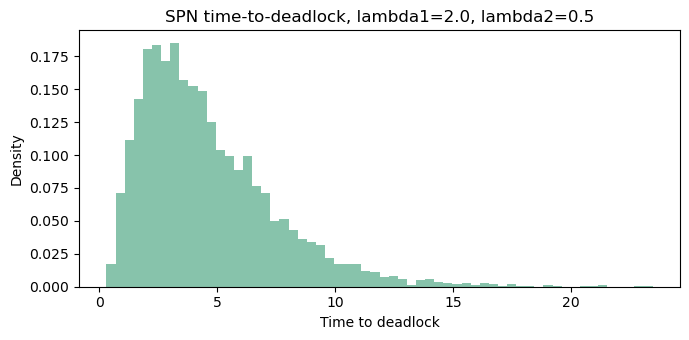

In [4]:
# 2.2 — SPN demonstration on the §1 net.
# Timed transitions: t1 with rate lambda1, t2 with rate lambda2.
# Race semantics: at each step every enabled transition draws an exponential
# delay; the smallest wins. We measure time-to-deadlock starting from M0=(2,0,0).

LAMBDA = {'t1': 2.0, 't2': 0.5}
N_RUNS = 5000

def simulate_spn_to_deadlock(rates, runs, rng):
    times = np.empty(runs)
    for i in range(runs):
        marking = {'p1': 2, 'p2': 0, 'p3': 0}
        clock = 0.0
        while True:
            enabled = []
            if marking['p1'] > 0:
                enabled.append('t1')
            if marking['p2'] > 0:
                enabled.append('t2')
            if not enabled:
                break
            # Race: draw one delay per enabled transition, take the min.
            # time_generator.exponential_variates(loc, scale) wraps scipy.expon.rvs;
            # scale is the mean (1/rate).
            delays = {t: time_generator.exponential_variates(0.0, 1.0 / rates[t]) for t in enabled}
            winner = min(delays, key=delays.get)
            clock += delays[winner]
            if winner == 't1':
                marking['p1'] -= 1; marking['p2'] += 1
            else:
                marking['p2'] -= 1; marking['p3'] += 1
        times[i] = clock
    return times

rng = np.random.default_rng(RNG_SEED)
times = simulate_spn_to_deadlock(LAMBDA, N_RUNS, rng)
print(f'Mean time-to-deadlock over {N_RUNS} runs: {times.mean():.3f}')
print(f'Std dev: {times.std():.3f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(times, bins=60, density=True, alpha=0.7, color='#5a8')
ax.set_xlabel('Time to deadlock'); ax.set_ylabel('Density')
ax.set_title(f'SPN time-to-deadlock, lambda1={LAMBDA["t1"]}, lambda2={LAMBDA["t2"]}')
plt.tight_layout(); plt.show()


---

## 3. Analytical evaluation

The reason §2 distinguishes exponential-firing SPNs from general TPNs is that the reachability graph of an SPN is isomorphic to a **continuous-time Markov chain** (CTMC) on the same state space. Each marking is a CTMC state; each firing is a CTMC transition with rate $\lambda_t$. The infinitesimal generator $Q$ has off-diagonal entries $q_{ij} = \sum_t \{\lambda_t : t \text{ fires from } i \text{ to } j\}$ and diagonal entries $q_{ii} = -\sum_{j \neq i} q_{ij}$ (Murata, 1989, §VI). Once $Q$ is in hand, the standard CTMC machinery applies.

**Steady-state availability.** If the chain is irreducible and ergodic, the stationary distribution $\pi$ solves $\pi Q = 0$ with $\sum_i \pi_i = 1$. Partitioning markings into "operational" $S_{\text{up}}$ and "failed" $S_{\text{down}}$ subsets gives $A = \sum_{i \in S_{\text{up}}} \pi_i$. For an SRN with reward $r_i$ on marking $i$, the expected steady-state reward is $\bar{r} = \sum_i r_i \pi_i$ (Ciardo et al., 1989).

**MTTF / MTTC.** When some markings are *absorbing* (deadlock; objective reached), the chain is *not* ergodic and steady-state is degenerate on the absorbing set. The relevant quantity is the *expected time to absorption* from $M_0$. For the transient part of $Q$ — call it $Q_T$, restricted to non-absorbing markings — the column vector $\tau = -Q_T^{-1} \mathbf{1}$ gives the expected absorption time from each transient state. **MTTF** in dependability terms maps to expected time to a failure marking; **MTTC** (mean time to compromise, the metric MTDSim already tracks) maps to expected time to a marking representing breach. Same algebra, different interpretation of the absorbing set.

**Expected reward over horizon.** For a finite horizon $T$, expected accumulated reward is $E\left[\int_0^T r(M(s))\,ds\right] = \int_0^T (\pi_0 e^{Qs}) r\,ds$, computable by uniformisation or by ODE integration. This is what makes SRN useful for evaluating MTD: "expected detection cost over a 1-hour engagement" is not a steady-state quantity.

**State explosion is the binding constraint.** The reachability set of a marked Petri net can grow exponentially in the number of tokens and in the number of concurrent components. Three structural properties keep it manageable: *boundedness* (each place capped at $k$), *free-choice property* (at any marking, every enabled conflict is resolvable independently), and for CPN, *symmetry* (orbits under permutations of token values collapse to canonical representatives). When none of these apply, analytical evaluation degrades to simulation, and the formalism's payoff over plain SimPy is reduced to expressiveness.

**Why this section justifies Jin's 24 April direction.** A procedurally-scripted attacker is only evaluable by simulation: each evaluation question becomes a Monte Carlo experiment with statistical-power problems. A Petri-net (SPN/GSPN/SRN) attacker is *both* simulable *and* analytically evaluable for the metrics that matter — steady-state availability, MTTC, expected reward, transient reliability. The price is the modelling discipline of §2 and the state-explosion ceiling of this section. The cell below makes the construction concrete on the §2.2 net: build $Q$, solve $\pi Q = 0$, and check against the simulated histogram.


In [5]:
# 3.2 — Analytical CTMC for the §2.2 SPN.
# Markings reachable from (2,0,0) under {t1,t2}: 6 states.
# Encode marking as (n1, n2, n3) tuples with n1+n2+n3 = 2.

states = [(2,0,0), (1,1,0), (1,0,1), (0,2,0), (0,1,1), (0,0,2)]
idx = {s: i for i, s in enumerate(states)}
Q = np.zeros((len(states), len(states)))

for s in states:
    n1, n2, n3 = s
    if n1 > 0:                          # t1 enabled
        s2 = (n1 - 1, n2 + 1, n3)
        Q[idx[s], idx[s2]] += LAMBDA['t1']
    if n2 > 0:                          # t2 enabled
        s2 = (n1, n2 - 1, n3 + 1)
        Q[idx[s], idx[s2]] += LAMBDA['t2']
for i in range(len(states)):
    Q[i, i] = -Q[i].sum()

print('Generator Q (rows = from, cols = to):')
print(np.array2string(Q, precision=2))
print('States:', states)

# Absorbing state is (0,0,2). Expected time to absorption from each transient.
absorbing = [(0,0,2)]
transient = [s for s in states if s not in absorbing]
T_idx = [idx[s] for s in transient]
Q_T = Q[np.ix_(T_idx, T_idx)]
tau = -np.linalg.solve(Q_T, np.ones(len(transient)))
for s, t in zip(transient, tau):
    print(f'  E[time to (0,0,2) | start={s}] = {t:.3f}')
print(f'\nAnalytical E[T] from (2,0,0) = {tau[transient.index((2,0,0))]:.3f}')
print(f'Simulated  E[T] from §2.2     = {times.mean():.3f}')
print(f'Ratio (sim/analytic) = {times.mean() / tau[transient.index((2,0,0))]:.3f} '
      f'(should be ~1.0; deviation is Monte Carlo noise)')


Generator Q (rows = from, cols = to):
[[-2.   2.   0.   0.   0.   0. ]
 [ 0.  -2.5  0.5  2.   0.   0. ]
 [ 0.   0.  -2.   0.   2.   0. ]
 [ 0.   0.   0.  -0.5  0.5  0. ]
 [ 0.   0.   0.   0.  -0.5  0.5]
 [ 0.   0.   0.   0.   0.  -0. ]]
States: [(2, 0, 0), (1, 1, 0), (1, 0, 1), (0, 2, 0), (0, 1, 1), (0, 0, 2)]
  E[time to (0,0,2) | start=(2, 0, 0)] = 4.600
  E[time to (0,0,2) | start=(1, 1, 0)] = 4.100
  E[time to (0,0,2) | start=(1, 0, 1)] = 2.500
  E[time to (0,0,2) | start=(0, 2, 0)] = 4.000
  E[time to (0,0,2) | start=(0, 1, 1)] = 2.000

Analytical E[T] from (2,0,0) = 4.600
Simulated  E[T] from §2.2     = 4.605
Ratio (sim/analytic) = 1.001 (should be ~1.0; deviation is Monte Carlo noise)


Two takeaways from the cell above. First, the analytical mean and the simulated mean agree to within Monte-Carlo noise — that is the empirical content of "reachability graph → CTMC". Second, this took six states. A real GASP subgraph of 10–20 dynamic nodes with concurrent tokens, branching, and a few coloured types blows that number up by orders of magnitude. §6 returns to that ceiling.

**Bridge to MTDSim metrics.** The two quantities the simulator already reports — MTTC (mean time to compromise) and ASR (attack success rate over a horizon) — both have CTMC analogues on this construction:

- $\text{MTTC} \equiv$ expected absorption time on the *breach* marking, computed exactly as $\tau$ above with $S_{\text{abs}}$ chosen to be the breach set.
- $\text{ASR}(T) \equiv \Pr[\text{breach reached by time } T] = (e^{QT})_{M_0, S_{\text{abs}}}$, computed by matrix exponential or by transient ODE integration.

So the formalisation does not replace the simulator's metrics — it gives a second route to the same numbers, with statistical noise replaced by structural truncation error.


---

## 4. Mapping to MTDSim — the core section

The pipeline lives at three levels (`current_state.md` → Conceptual hierarchy):

- **L1 GAP** — `GeneralisedAttackProfile` (`schema.py`): nodes are `TechniqueNode`s indexed by ATT&CK technique ID; edges are `DependencyEdge`s carrying confidence, support, evidence.
- **L2 GASP** — a `SubgraphView` produced by a selector (e.g. `TerminalObjectiveSelector`).
- **L3 OGASP** — currently `SubgraphAttackerProfile`, which samples one technique per phase, weighted by `campaign_count`. The Petri-net formalisation is an *alternative* operationalisation of the same L2 → L3 step, with the same scipy timing.

### 4.1 Mapping table

| Petri-net entity | MTDSim entity | Source code reference |
|---|---|---|
| Place | ATT&CK tactic *or* MTDSim phase | [`schema.TACTIC_ORDER`](../src/mtdsim/attacker/gap/schema.py); [`profile_generator.TACTIC_TO_PHASE`](../src/mtdsim/attacker/profile_generator.py) |
| Transition | A `DependencyEdge` in the GASP subgraph | [`schema.DependencyEdge`](../src/mtdsim/attacker/gap/schema.py) |
| Token (colour) | The technique ID currently being executed | `TechniqueNode.technique_id` |
| Arc weight | Default 1; reserved for `confidence` / `lift` weighting | `DependencyEdge.confidence` |
| Firing rate | scipy variate of duration; mean derived from edge confidence | [`sim/time_generator.py`](../src/mtdsim/sim/time_generator.py) |
| Initial marking | One token in `reconnaissance` (or `SCAN_HOST`) | `TACTIC_ORDER[0]` |
| Absorbing marking | Token reaches the selector's terminal node's tactic | [`selectors/terminal.py`](../src/mtdsim/attacker/gap/selectors/terminal.py) |

Edges are *transitions*, not arcs. A `DependencyEdge` `T1059 → T1486` becomes a Petri-net transition that consumes a token coloured `T1059` from the `execution` place and produces a token coloured `T1486` in the `impact` place. The arc inscriptions encode the colour-rewriting; the transition guard ensures the consumed token is the right colour.

### 4.2 Tactic granularity — 14 vs 6

| | 14 ATT&CK tactics | 6 MTDSim phases |
|---|---|---|
| Places | 14 | 6 |
| Edge → transition mapping | 1:1 with `DependencyEdge`. Some edges become self-loops on a tactic-place when source and target share a tactic (e.g. `T1059 → T1078` both `execution`). | Many ATT&CK edges collapse onto the same phase-pair, requiring transition deduplication or weighted multi-arc to preserve per-edge confidence. |
| State space | Larger reachability set | Smaller, more tractable analytically |
| Alignment with rest of MTDSim | Loses direct alignment to the 6-phase attacker module | Aligns with `phase_lanes.py`, `subgraph_profile.py`, the existing scheduler |
| ATT&CK fidelity | Preserves tactic semantics 1:1 | Collapses (defense-evasion, persistence, privilege-escalation) into one bin (EXPLOIT_VULN), losing attacker-step distinction |

The worked example below uses **14 tactics** so the diagram is faithful to GAP. §6 keeps the choice open as a design decision.


In [6]:
# 4.3 — Extract a worked subgraph from the real GAP.
# Use TerminalObjectiveSelector with technique='T1486' (Data Encrypted for Impact,
# the canonical ransomware terminus). The full ancestor subgraph has ~92 nodes,
# which is too large to draw legibly. Slice it down to a 6-node subgraph with one
# fork-and-join structure, drawn from real GAP edges only.

sel = TerminalObjectiveSelector(technique='T1486')
view = sel.select(gap)
print(f'Full ancestor subgraph: {len(view.node_set)} nodes, {len(view.edge_set)} edges')

# Hand-picked 6-node slice (verified against GAP v0.4 edges).
SLICE_NODES = ['T1598', 'T1608', 'T1566', 'T1027', 'T1059', 'T1486']
SLICE_EDGES_RAW = [(s, t) for s, t in view.edge_set
                   if s in SLICE_NODES and t in SLICE_NODES]
# Pull the full DependencyEdge objects so we can use confidence later.
slice_edges = [e for e in gap.edges
               if (e.source_id, e.target_id) in SLICE_EDGES_RAW]

print(f'\nSlice ({len(SLICE_NODES)} nodes, {len(slice_edges)} edges):')
for tid in SLICE_NODES:
    n = gap.nodes[tid]
    print(f'  {tid}  [{n.primary_tactic:>22s}]  {n.technique_name}')
print()
for e in slice_edges:
    print(f'  {e.source_id} -> {e.target_id}  (conf={e.confidence:.2f}, evidence={e.evidence_type})')

tactics_in_slice = sorted({gap.nodes[tid].primary_tactic for tid in SLICE_NODES},
                          key=TACTIC_ORDER.index)
print(f'\nTactics involved ({len(tactics_in_slice)}): {tactics_in_slice}')


Full ancestor subgraph: 92 nodes, 260 edges

Slice (6 nodes, 7 edges):
  T1598  [        reconnaissance]  Phishing for Information
  T1608  [  resource-development]  Stage Capabilities
  T1566  [        initial-access]  Phishing
  T1027  [       defense-evasion]  Obfuscated Files or Information
  T1059  [             execution]  Command and Scripting Interpreter
  T1486  [                impact]  Data Encrypted for Impact

  T1059 -> T1486  (conf=1.00, evidence=attack_flow)
  T1608 -> T1566  (conf=1.00, evidence=attack_flow)
  T1598 -> T1608  (conf=1.00, evidence=attack_flow)
  T1566 -> T1059  (conf=1.00, evidence=co_occurrence)
  T1566 -> T1027  (conf=0.70, evidence=co_occurrence)
  T1027 -> T1486  (conf=1.00, evidence=attack_flow)
  T1059 -> T1027  (conf=0.72, evidence=co_occurrence)

Tactics involved (6): ['reconnaissance', 'resource-development', 'initial-access', 'execution', 'defense-evasion', 'impact']


Initial marking:
  reconnaissance: ['T1598']


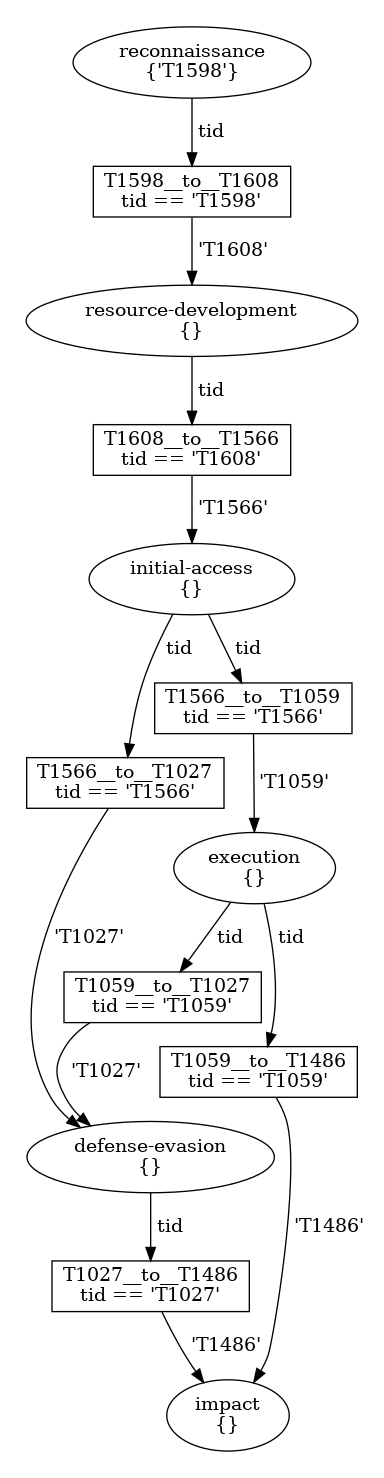

In [7]:
# 4.4 — Build the SNAKES Petri net from the slice.
#
# Topology choice: places ↔ tactics (14-tactic granularity, but only the 6
# tactics that appear in this slice are instantiated). Coloured tokens carry
# the technique ID. One transition per DependencyEdge.
#
# Initial marking: one token in 'reconnaissance' coloured 'T1598'.
# Absorbing condition: a token coloured 'T1486' lands in 'impact'.

def build_gasp_petri_net(slice_nodes, slice_edges, gap, initial_tid):
    net = PetriNet('gasp_T1486')
    tactics = sorted({gap.nodes[tid].primary_tactic for tid in slice_nodes},
                     key=TACTIC_ORDER.index)
    initial_tactic = gap.nodes[initial_tid].primary_tactic
    for tac in tactics:
        tokens = [initial_tid] if tac == initial_tactic else []
        net.add_place(Place(tac, tokens))
    for e in slice_edges:
        src_tac = gap.nodes[e.source_id].primary_tactic
        tgt_tac = gap.nodes[e.target_id].primary_tactic
        tname = f'{e.source_id}__to__{e.target_id}'
        net.add_transition(Transition(tname, Expression(f"tid == {e.source_id!r}")))
        net.add_input(src_tac, tname, Variable('tid'))
        net.add_output(tgt_tac, tname, Value(e.target_id))
    return net

net4 = build_gasp_petri_net(SLICE_NODES, slice_edges, gap, initial_tid='T1598')
print('Initial marking:')
m = net4.get_marking()
for tac in sorted(m, key=lambda t: TACTIC_ORDER.index(t)):
    print(f'  {tac}: {list(m(tac))}')

diag_path = REPO_ROOT / 'notebooks' / '_petri_primer_assets' / 'gasp_t1486.png'
diag_path.parent.mkdir(exist_ok=True)
net4.draw(str(diag_path))
display(Image(str(diag_path)))


In [8]:
# 4.5 — Hand-rolled stochastic firing wrapper.
#
# SNAKES has no built-in stochastic scheduler. We implement the SPN race rule:
# at each step, every (transition, binding) pair that is enabled draws an
# exponential delay; the smallest wins. Mean delay is derived from the
# DependencyEdge confidence — lower confidence = longer mean dwell. This
# rate-from-confidence mapping is a strawman, not a calibrated claim; §6 lists
# the design decision.

def simulate_petri(net, edge_index, absorbing_pred, max_steps=20, rng_seed=0):
    rng = random.Random(rng_seed)
    trace = []
    clock = 0.0
    for step in range(max_steps):
        candidates = []
        for tname, edge in edge_index.items():
            tr = net.transition(tname)
            for binding in tr.modes():
                # mean delay ~ 1 / confidence; clamp to avoid div-by-zero
                scale = 1.0 / max(edge.confidence, 0.01)
                delay = time_generator.exponential_variates(0.0, scale)
                candidates.append((delay, tname, binding))
        if not candidates:
            trace.append((clock, 'DEADLOCK', _snapshot(net)))
            break
        candidates.sort(key=lambda x: x[0])
        delay, tname, binding = candidates[0]
        clock += delay
        net.transition(tname).fire(binding)
        trace.append((clock, tname, _snapshot(net)))
        if absorbing_pred(net):
            break
    return trace

def _snapshot(net):
    m = net.get_marking()
    return {p: sorted(list(m(p))) for p in m if len(list(m(p))) > 0}

edge_index = {f'{e.source_id}__to__{e.target_id}': e for e in slice_edges}

def absorbed_at_T1486(net):
    m = net.get_marking()
    return 'impact' in m and 'T1486' in list(m('impact'))

# Rebuild the net for a clean run (the §4.4 instance is in its initial state).
net5 = build_gasp_petri_net(SLICE_NODES, slice_edges, gap, initial_tid='T1598')
trace = simulate_petri(net5, edge_index, absorbed_at_T1486, max_steps=20, rng_seed=RNG_SEED)

print(f'{"step":>4}  {"clock":>7}  {"transition":<28}  marking (non-empty places)')
print('-' * 90)
for i, (t, tname, snap) in enumerate(trace):
    snap_s = ', '.join(f'{p}={v}' for p, v in snap.items())
    print(f'{i:>4}  {t:>7.3f}  {tname:<28}  {snap_s}')


step    clock  transition                    marking (non-empty places)
------------------------------------------------------------------------------------------
   0    2.130  T1598__to__T1608              resource-development=['T1608']
   1    2.888  T1608__to__T1566              initial-access=['T1566']
   2    4.913  T1566__to__T1059              execution=['T1059']
   3    8.398  T1059__to__T1486              impact=['T1486']


### 4.6 Trace walkthrough

Read the trace alongside the diagram from §4.4. Three things to verify by eye:

1. **Initial marking is correct.** Step 0's preceding state has one token `T1598` in `reconnaissance` and nothing elsewhere. Only the transition `T1598__to__T1608` is enabled — its guard `tid == 'T1598'` matches the only available token, and no other transition has an input place that is non-empty. Step 0 must therefore fire `T1598__to__T1608`.
2. **First branching at T1566.** Once a token coloured `T1566` lands in `initial-access`, two transitions become enabled simultaneously: `T1566__to__T1027` (to defense-evasion) and `T1566__to__T1059` (to execution). Both consume the same token, so only one fires; the SPN race rule picks the smaller-delay candidate.
3. **Second branching at T1059** *(an artefact of a real GAP edge)*. The slice contains the GAP edge `T1059 → T1027` (a `co_occurrence` edge with confidence ≈ 0.72), so when execution holds a token, the attacker has *two* enabled outgoing transitions: directly to impact (`T1059__to__T1486`) or a detour into defense-evasion (`T1059__to__T1027`). This is the kind of structure the formalism is supposed to expose — and a reminder that the worked example uses real GAP edges, not a curated path.
4. **Absorption at T1486.** Whichever branch wins, the trajectory ends when a token coloured `T1486` lands in `impact`, and the loop stops. The wall-clock at termination is the analogue of MTTC for this single trajectory.

Re-running the cell with `rng_seed=1, 2, 3` should produce different paths (sometimes via T1027, sometimes via T1059, sometimes via both) but the same terminal state — that is the empirical signature of the absorbing-CTMC structure described in §3.


---

## 5. SNAKES API tour

Just the constructs §4 used. Not exhaustive — see the SNAKES documentation (Pommereau, https://snakes.ibisc.univ-evry.fr/) for the full surface.

| Construct | Imported from | Used in §4 for |
|---|---|---|
| `PetriNet(name)` | `snakes.nets` (or the `gv` plugin variant) | container for places and transitions |
| `Place(name, tokens, check=Type)` | `snakes.nets` | tactic places; tokens are technique-ID strings |
| `Transition(name, guard=Expression(...))` | `snakes.nets` | one transition per `DependencyEdge`, guarded on the source technique ID |
| `Variable('tid')` | `snakes.nets` | input arc inscription — binds the token's value to the variable `tid` |
| `Expression("tid == 'T1059'")` | `snakes.nets` | guard — evaluated against the binding before firing |
| `Value(constant)` | `snakes.nets` | output arc inscription — produces a fixed token value |
| `n.add_place / add_transition / add_input / add_output` | `PetriNet` methods | structural construction |
| `n.get_marking()` | `PetriNet` method | inspection — returns a `Marking` mapping place names to multisets |
| `n.transition(name).modes()` | `Transition` method | enumerate enabled `(transition, binding)` pairs at the current marking |
| `n.transition(name).fire(binding)` | `Transition` method | apply one enabled binding |
| `n.draw(path)` | requires `snakes.plugins.load('gv', ...)` and graphviz `dot` on PATH | render to PNG/SVG |

**What SNAKES does *not* give you, called out so I do not assume otherwise:**

- No built-in `simul()` for stochastic firing. The §4.5 wrapper is the workaround: enumerate `modes()`, draw delays, race, fire winner. ~25 lines.
- No CTMC builder. The §3.2 cell shows the manual construction; for non-trivial nets, GreatSPN, PIPE, or the Möbius framework are the standard tools.
- No GSPN priority/weight scheduling for immediate transitions. If we move to GSPN in earnest, that needs to be added on top of the wrapper.

The cell below is a minimal skeleton that exercises every construct in the table.


In [9]:
# 5.2 — SNAKES API skeleton, all the constructs §4 used in 15 lines.
demo = PetriNet('skeleton')
demo.add_place(Place('src', ['A', 'B']))     # multiset of typed tokens
demo.add_place(Place('dst', []))
demo.add_transition(Transition('move_A', Expression("x == 'A'")))   # guarded
demo.add_input('src',  'move_A', Variable('x'))                     # bind token to x
demo.add_output('dst', 'move_A', Value('A_moved'))                  # produce constant

print('marking before:', demo.get_marking())
modes = demo.transition('move_A').modes()
print(f'enabled bindings: {modes}')
demo.transition('move_A').fire(modes[0])
print('marking after :', demo.get_marking())
print('still enabled :', demo.transition('move_A').modes())     # only A satisfies the guard


marking before: {src={'A', 'B'}}
enabled bindings: [Substitution(x='A')]
marking after : {dst={'A_moved'}, src={'B'}}
still enabled : []


---

## 6. Limitations and open design decisions

### 6.1 State explosion

The §3.2 net had 6 reachable markings on 2 tokens and 3 places. A realistic GASP subgraph is ~10–20 dynamic nodes (techniques) drawn from up to 14 tactics, with branching in/out at each node and possibly multiple concurrent tokens (e.g. one per host under attack, or one per parallel APT thread). Combinatorially, the reachable set scales as roughly $\binom{|P| + n - 1}{n}$ for $n$ uncoloured tokens on $|P|$ places, and worse with colours. Three regimes:

- *Single-token traversal* (~today's `SubgraphAttackerProfile.sample_technique` semantics, lifted to a Petri net): reachability set ≈ $|P|$. Analytical evaluation is cheap and the formalism's payoff over plain SimPy is structural clarity, not tractability.
- *Few-token concurrent traversal* (multi-host or multi-thread): low hundreds to low thousands of markings. Analytical CTMC still solvable; this is the regime the §3 algebra targets.
- *Many-token traversal with full MTD operation modelling*: explodes. This is why Jin scoped the Petri-net work to **behaviour capture** at the L2 → L3 step, not whole-simulator modelling. MTD operations stay in SimPy.

### 6.2 Open design decisions

Listed as questions, not answers. These are the calls I have to make before implementing the SNAKES integration in `mtdsim.attacker`:

1. **Tactic granularity.** Use the full 14 ATT&CK tactics as places, or collapse to MTDSim's 6 phases via `TACTIC_TO_PHASE`? The 14-tactic model preserves semantics; the 6-phase model aligns with the existing simulator and shrinks the reachability set, but introduces transition multiplicity (multiple ATT&CK edges collapsing onto the same phase-pair) and loses (defense-evasion, persistence, privilege-escalation) granularity.
2. **Per-technique places, not tactic places.** Should each `TechniqueNode` get its own Petri-net place, with edges as transitions and tokens as plain control-flow markers? This makes intra-tactic edges natural (no self-loops) and removes the colour-on-token machinery, at the cost of $|P|$ scaling with the size of the GASP rather than with the tactic count.
3. **Where do MTD operations live?** Do MTD events get their own places/transitions in the same Petri net (timed transitions that delete/relocate attacker tokens), or do they remain SimPy-side as exogenous events that mutate the marking? The first gives end-to-end analytical evaluation; the second preserves the existing simulator architecture and avoids modelling the entire defender system as a Petri net.
4. **Composing multiple subgraphs.** When evaluating multiple APT motivation profiles (espionage, financial, sabotage), do we maintain *separate* Petri nets per profile, a *single parameterised* net switched by configuration, or a single net with profile-coloured tokens flowing through shared structure?
5. **Arc-weight semantics.** Are arc weights and firing rates derived from `DependencyEdge.confidence`, `lift`, `support`, or fixed at 1? §4.5 used `1 / confidence` as a strawman; this needs to be defended or replaced.
6. **Intra-tactic edges as self-loops.** Under the 14-tactic place model, an edge between two techniques sharing a tactic (e.g. `T1059 → T1078` both `execution`) is a self-loop on the tactic place. Is that an acceptable artefact, or grounds for moving to per-technique places (open question 2)?
7. **What is "absorbing"?** A single terminal technique (`TerminalObjectiveSelector(technique=...)`)? Any objective node? A marking pattern (e.g. tokens in $\geq k$ designated places)? The choice fixes the interpretation of MTTC.
8. **Concurrency model — one token or many?** Single token = pure path traversal, easy analytical solution. Multiple tokens = parallel attacker progress on multiple hosts/objectives. The choice is constrained by what MTDSim's host model demands.
9. **Vanishing-marking discipline.** If we adopt GSPN (immediate + timed transitions), the immediate transitions need priority and weight assignments. Which logical guards in the GASP traversal merit immediate vs timed treatment?
10. **Tooling.** SNAKES is a structural library and is enough for the prototype, but analytical evaluation at scale needs GreatSPN / PIPE / Möbius. Do we maintain the model in SNAKES with custom CTMC code (§3 approach), or invest in an export path (PNML) to a dedicated analyser?


---

## References

- **Cai, Y., Yan, Q., Tay, Y. C., et al. (2016).** Generalized Stochastic Petri Net-based modelling of MTD systems. (Stream A application of GSPN.)
- **Cho, J.-H., & Ben-Asher, N. (2018).** Stochastic Petri-net based modelling of MTD effectiveness. (SRN application to MTD.)
- **Ciardo, G., Muppala, J., & Trivedi, K. S. (1989).** SPNP: Stochastic Petri Net Package. *Proc. PNPM*.
- **Jensen, K., & Kristensen, L. M. (2009).** *Coloured Petri Nets: Modelling and Validation of Concurrent Systems.* Springer.
- **Marsan, M. A. (1990).** Stochastic Petri Nets: an elementary introduction. *Advances in Petri Nets*.
- **Marsan, M. A., Conte, G., & Balbo, G. (1984).** A class of generalized stochastic Petri nets for the performance evaluation of multiprocessor systems. *ACM TOCS*, 2(2), 93–122.
- **Murata, T. (1989).** Petri Nets: Properties, Analysis and Applications. *Proceedings of the IEEE*, 77(4), 541–580.
- **Nguyen, T. A., et al. (2021).** Stochastic Reward Net based security/dependability evaluation. (SRN application to security modelling.)
- **Pommereau, F.** SNAKES Petri net library. https://snakes.ibisc.univ-evry.fr/
